In [26]:
import pandas as pd
import os
import re
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import copy

data = pd.read_excel(r'Запчасти списанные в ремонт.xls', skiprows=[0, 1, 2, 3, 4, 5, 6, 7 ,8], dtype=str)
data = data.drop(columns=['Unnamed: 1', 'Unnamed: 5', 'Unnamed: 6'])
data = data.iloc[:-1].reset_index(drop=True)
conditions = [
    data['Машина'].str.contains('ножничный', case=False, na=False),
    data['Машина'].str.contains('коленчатый', case=False, na=False),
    data['Машина'].str.contains('телескопический', case=False, na=False),
    data['Машина'].str.contains('мачтовый', case=False, na=False)
]
choices = ['ножничный', 'коленчатый', 'телескопический', 'мачтовый']

data['Тип подъемника'] = np.select(conditions, choices, default='другое')
df = copy.deepcopy(data)
df.info()
df.shape[0]

<class 'pandas.DataFrame'>
RangeIndex: 14167 entries, 0 to 14166
Data columns (total 17 columns):
 #   Column                                       Non-Null Count  Dtype
---  ------                                       --------------  -----
 0   Дата                                         14167 non-null  str  
 1   Год                                          14167 non-null  str  
 2   Месяц                                        14167 non-null  str  
 3   Номенклатура                                 14167 non-null  str  
 4   Номенклатура.Бренд                           14167 non-null  str  
 5   Номенклатура.Оригинальный номер              12443 non-null  str  
 6   Номенклатура.Артикул                         14116 non-null  str  
 7   Номенклатура.Оригинальный номер расширенный  9200 non-null   str  
 8   Машина                                       14167 non-null  str  
 9   Машина.Двигатель                             2751 non-null   str  
 10  Машина.Бренд                     

14167

In [27]:
# Фильтра
filters = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(фильтр|комплект фильтров|элемент фильтра)',
        regex=True,
        na=False
    )
]

filters.to_excel('Фильра.xlsx', index=False)

# Замки
locks = df[
    df['Номенклатура'].str.contains('замок', case=False, na=False)
]

locks.to_excel('Замки.xlsx', index=False)

# Кнопки
buttons = df[
    df['Номенклатура'].str.contains('кнопка', case=False, na=False)
]

buttons.to_excel('Кнопки.xlsx', index=False)

# Батареи
bat = df[
    df['Номенклатура'].str.contains('батарея', case=False, na=False)
]

bat.to_excel('Батареи.xlsx', index=False)

# Обогреватели
heater = df[
    df['Номенклатура'].str.contains('|'.join(['обогреватель', 'нагреватель', 'подогреватель']), case=False, na=False)
]

heater.to_excel('Обогреватели.xlsx', index=False)

# Разъемы
socket = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(разъем)',
        regex=True,
        na=False
    )
]

socket.to_excel('Разъемы.xlsx', index=False)

# Пластины
plate = df[
    df['Номенклатура'].str.contains('пластина', case=False, na=False)
]

plate.to_excel('Пластины.xlsx', index=False)

# Масла
oil = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(масло)',
        regex=True,
        na=False
    )
]

oil.to_excel('Масла.xlsx', index=False)

# Ключи
key = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(ключ)',
        regex=True,
        na=False
    )
]

key.to_excel('Ключи.xlsx', index=False)

# Джойстики
mask_include = df['Номенклатура'].str.contains('|'.join(['джойстик', 'электроджойстик']), case=False, na=False)
mask_exclude = ~df['Номенклатура'].str.contains('рукоятка', case=False, na=False)

joystick = df[mask_include & mask_exclude]

joystick.to_excel('Джойстики.xlsx', index=False)

# Рукава
sleeve = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(рукав)',
        regex=True,
        na=False
    )
]

sleeve.to_excel('Рукава.xlsx', index=False)

# Кабели
cables = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(кабель)',
        regex=True,
        na=False
    )
]

cables.to_excel('Кабеля.xlsx', index=False)

# Тройники
splitter = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(тройник)',
        regex=True,
        na=False
    )
]

splitter.to_excel('Тройники.xlsx', index=False)

# Штуцера
fitting = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(штуцер)',
        regex=True,
        na=False
    )
]

fitting.to_excel('Штуцера.xlsx', index=False)

# ЗУ
charger = df[
    df['Номенклатура'].str.contains('|'.join(['зу', 'устройство зарядное', 'Устройство зарядное', 'Зарядное устройство', 'зарядное устройство']), case=False, na=False)
]
charger = charger[charger['Номенклатура'] != 'ЗУБР МЕХАНИК, размер L, перчатки маслобензостойкие тонкие 11276-L_z01']

charger.to_excel('ЗУ.xlsx', index=False)

# Клапаны
valve = df[
    df['Номенклатура'].str.contains('|'.join(['клапан']), case=False, na=False)
]
lst = [
    'Блок клапанов 92049371A',
    'Прокладка клапанной крышки 713115700',
    'Гидроцилиндр поворота люльки ZA20 (х8) 1010201471 без блока клапанов',
    'Соленоид электромагнитного клапана поворота колёс 92047788'
]
valve = valve[~valve['Номенклатура'].isin(lst)]
valve.to_excel('Клапана.xlsx', index=False)

# Наклейки
stickers = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(наклейка)',
        regex=True,
        na=False
    )
]
stickers.to_excel('Наклейки.xlsx', index=False)

# Тройники
splitter = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(тройник)',
        regex=True,
        na=False
    )
]

splitter.to_excel('Тройники.xlsx', index=False)

# Маячки
beacons = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(маячок)',
        regex=True,
        na=False
    )
]
beacons.to_excel('Маячки.xlsx', index=False)

# Датчики
sensors = df[
    df['Номенклатура'].str.contains('|'.join(['датчик']), case=False, na=False)
]
lst = ['Кронштейн датчика угла 93300721', 'Контакт датчика поворота колеса BA36-44 93300156A',
       'Скоба датчика BA36,BA44 50011001A', 'Контакт датчика поворота колеса BA36-44 93300156A'
]
sensors = sensors[~sensors['Номенклатура'].isin(lst)]
sensors.to_excel('Датчики.xlsx', index=False)

# Чехлы
cover = df[
    df['Номенклатура'].str.contains('|'.join(['чехол', 'термочехол']), case=False, na=False)
]
cover.to_excel('Чехлы.xlsx', index=False)

# Жгуты
harness = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(жгут)',
        regex=True,
        na=False
    )
]
harness.to_excel('Жгуты.xlsx', index=False)

# Пальцы
fingers = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(палец)',
        regex=True,
        na=False
    )
]
fingers.to_excel('Пальцы.xlsx', index=False)

df['Номенклатура'].value_counts()[:20]

C:\Users\a.vorona\AppData\Local\Temp\ipykernel_21684\2344652225.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_21684\2344652225.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_21684\2344652225.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_21684\2344652225.py:83: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_21684\2344652225.py:105: UserWarning: This pattern is interpreted as a

Номенклатура
Фильтр воздушный внешний DIFA 4382 + внутренний DIFA 4382-01    808
Фильтр топливный 1009806735                                     438
Фильтр топливный  Weichai  1000002416                           433
Фильтр топливный ST20754C                                       344
Батарея тяговая 12V 145Ah QUIMO Q-1275  330*180*250             332
Фильтр топливный SFC62030                                       332
Фильтр топливный 1009806734                                     323
Фильтр топливный DIFA 6113                                      291
Батарея тяговая 6V 230Ah QUIMO Q-125  260*180*256               267
Фильтр масляный 1009806741                                      264
Фильтр гидравлический 1010601571                                263
Фильтр масляный 1009806733                                      258
Фильтр масляный  Weichai  1001740614                            252
Разъем ВПУ сборе LGMG  25300003271                              242
Разъем НПУ в сборе LGMG 25300003281

In [28]:
filters_list = set(filters['Номенклатура'])
sensors_list = set(sensors['Номенклатура'])
fingers_list = set(fingers['Номенклатура'])
harness_list = set(harness['Номенклатура'])
cover_list = set(cover['Номенклатура'])
beacons_list = set(beacons['Номенклатура'])
splitter_list = set(splitter['Номенклатура'])
stickers_list = set(stickers['Номенклатура'])
valve_list = set(valve['Номенклатура'])
charger_list = set(charger['Номенклатура'])
fitting_list = set(fitting['Номенклатура'])
cables_list = set(cables['Номенклатура'])
sleeve_list = set(sleeve['Номенклатура'])
joystick_list = set(joystick['Номенклатура'])
key_list = set(key['Номенклатура'])
oil_list = set(oil['Номенклатура'])
plate_list = set(plate['Номенклатура'])
socket_list = set(socket['Номенклатура'])
heater_list = set(heater['Номенклатура'])
bat_list = set(bat['Номенклатура'])
buttons_list = set(buttons['Номенклатура'])
locks_list = set(locks['Номенклатура'])

In [36]:
df['Категория'] = 'другое'

df.loc[df['Номенклатура'].isin(filters_list), 'Категория'] = 'фильтр'
df.loc[df['Номенклатура'].isin(sensors_list), 'Категория'] = 'датчик'
df.loc[df['Номенклатура'].isin(fingers_list), 'Категория'] = 'палец'
df.loc[df['Номенклатура'].isin(harness_list), 'Категория'] = 'жгут'
df.loc[df['Номенклатура'].isin(cover_list), 'Категория'] = 'чехол'
df.loc[df['Номенклатура'].isin(beacons_list), 'Категория'] = 'маячок'
df.loc[df['Номенклатура'].isin(splitter_list), 'Категория'] = 'тройник'
df.loc[df['Номенклатура'].isin(stickers_list), 'Категория'] = 'наклейка'
df.loc[df['Номенклатура'].isin(valve_list), 'Категория'] = 'клапан'
df.loc[df['Номенклатура'].isin(charger_list), 'Категория'] = 'зу'
df.loc[df['Номенклатура'].isin(fitting_list), 'Категория'] = 'штуцер'
df.loc[df['Номенклатура'].isin(cables_list), 'Категория'] = 'кабель'
df.loc[df['Номенклатура'].isin(sleeve_list), 'Категория'] = 'рукав'
df.loc[df['Номенклатура'].isin(joystick_list), 'Категория'] = 'джойстик'
df.loc[df['Номенклатура'].isin(key_list), 'Категория'] = 'ключ'
df.loc[df['Номенклатура'].isin(oil_list), 'Категория'] = 'масло'
df.loc[df['Номенклатура'].isin(plate_list), 'Категория'] = 'пластина'
df.loc[df['Номенклатура'].isin(socket_list), 'Категория'] = 'разъем'
df.loc[df['Номенклатура'].isin(heater_list), 'Категория'] = 'обогреватель'
df.loc[df['Номенклатура'].isin(bat_list), 'Категория'] = 'батарея'
df.loc[df['Номенклатура'].isin(buttons_list), 'Категория'] = 'кнопка'
df.loc[df['Номенклатура'].isin(locks_list), 'Категория'] = 'замок'

In [97]:
def merge_numbers(row):
    orig = str(row['Номенклатура.Оригинальный номер'])
    ext = str(row['Номенклатура.Оригинальный номер расширенный'])
    # разбиваем по любому количеству пробелов
    ext_list = ext.split()
    if orig in ext_list:
        return ext  # уже есть — не добавляем
    else:
        return ext + ' ' + orig  # добавляем через пробел

filters['Аналоги'] = filters[filters['Номенклатура.Оригинальный номер расширенный'].notna()].apply(merge_numbers, axis=1)

In [98]:
filters

,Дата,Год,Месяц,Номенклатура,Номенклатура.Бренд,Номенклатура.Оригинальный номер,Номенклатура.Артикул,Номенклатура.Оригинальный номер расширенный,Машина,Машина.Двигатель,Машина.Бренд,Машина.Модель техники,Машина.Серия техники,Лот.CRM наработка,Документ.Склад,Количество,Тип подъемника,Аналоги
253,31.10.2022 17:00:26,2022,10,Фильтр воздушный 1000100311,Zoomlion,1000100311,1000100311,HP2556 1000100311 P829332,Подъёмник телескопический дизельный Zoomlion Z...,NaN,Zoomlion,ZT26J,ZT,NaN,ПО Сервисное обслуживание,16,телескопический,HP2556 1000100311 P829332
254,31.10.2022 17:00:26,2022,10,Фильтр воздушный 1000100310,Zoomlion,1000100310,1000100310,P827653 YM12993512520 4387912 0000000207...,Подъёмник телескопический дизельный Zoomlion Z...,NaN,Zoomlion,ZT26J,ZT,NaN,ПО Сервисное обслуживание,16,телескопический,P827653 YM12993512520 4387912 0000000207...
255,31.10.2022 17:00:26,2022,10,Фильтр топливный 1000400196,Zoomlion,1000400196,1000400196,1000400196 HH16643560 HH166-43560 ZP598B...,Подъёмник телескопический дизельный Zoomlion Z...,NaN,Zoomlion,ZT26J,ZT,NaN,ПО Сервисное обслуживание,12,телескопический,1000400196 HH16643560 HH166-43560 ZP598B...
256,31.10.2022 17:00:26,2022,10,Фильтр гидравлический G-0095D005ON,Zoomlion,1019902593,G-0095D005ON,G-0095D005ON 1019902593 SH75259 101980891...,Подъёмник телескопический дизельный Zoomlion Z...,NaN,Zoomlion,ZT26J,ZT,NaN,ПО Сервисное обслуживание,6,телескопический,G-0095D005ON 1019902593 SH75259 101980891...
257,31.10.2022 17:00:26,2022,10,Фильтр гидравлический G-0055D005ON,Zoomlion,1019902592,G-0055D005ON,HY13573 0055D005ON 1253012 SH75205 Н9999...,Подъёмник телескопический дизельный Zoomlion Z...,NaN,Zoomlion,ZT26J,ZT,NaN,ПО Сервисное обслуживание,6,телескопический,HY13573 0055D005ON 1253012 SH75205 Н9999...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14162,31.12.2025 23:59:58,2025,12,Фильтр топливный SFC62030,Sakura,4130241,SFC62030,FSK40022K 90031462,Подъемник коленчатый дизельный Dingli BA28BRT,NaN,Dingli,BA28BRT,BA,2400,Усть-Луга. Склад Запчастей для Сервиса,1,коленчатый,FSK40022K 90031462 4130241
14163,31.12.2025 23:59:58,2025,12,Фильтр топливный DIFA 6113,DIFA,6113,6113,04137456 FC25040 90031463,Подъемник коленчатый дизельный Dingli BA28BRT,NaN,Dingli,BA28BRT,BA,2400,Усть-Луга. Склад Запчастей для Сервиса,1,коленчатый,04137456 FC25040 90031463 6113
14164,31.12.2025 23:59:58,2025,12,Фильтр воздушный DIFA 43121,Dingli,90029290,43121,90029290 P608533 ST40111/ST40110 AF26656 ...,Подъемник коленчатый дизельный Dingli BA28BRT,NaN,Dingli,BA28BRT,BA,2400,Усть-Луга. Склад Запчастей для Сервиса,1,коленчатый,90029290 P608533 ST40111/ST40110 AF26656 ...
14165,31.12.2025 23:59:58,2025,12,Фильтр гидравлический 1010601865,Zoomlion,1010601865,1010601865,ST30057J 1010601225 1010602060,Подъемник коленчатый дизельный Zoomlion ZA24J,Двигатель дизельный CUMMINS QSF2.8t3TC72,Zoomlion,ZA24J,ZA,5178,ПТО СК запчасти для арендного парка,1,коленчатый,ST30057J 1010601225 1010602060 1010601865


In [ ]:
import pandas as pd
import networkx as nx

G = nx.Graph()

for idx, row in df.iterrows():
    ext = row['Номенклатура.Оригинальный номер расширенный']
    if pd.isna(ext):  # пропускаем пустые
        continue
    numbers = str(ext).split()  # приводим к строке и разбиваем по пробелу
    # соединяем все номера между собой
    for i in range(len(numbers)):
        for j in range(i+1, len(numbers)):
            G.add_edge(numbers[i], numbers[j])

# связные компоненты = группы аналогов
groups = list(nx.connected_components(G))

# создаём словарь: номер → группа
group_mapping = {}
for i, grp in enumerate(groups):
    for n in grp:
        group_mapping[n] = i

# создаём колонку с номером группы для каждой строки
def assign_group(ext):
    if pd.isna(ext):
        return None
    numbers = str(ext).split()
    # можно взять группу первой позиции
    return group_mapping.get(numbers[0], None)

df['Группа_аналогов'] = df['Номенклатура.Оригинальный номер расширенный'].apply(assign_group)

In [120]:
df.at[255, 'Номенклатура.Оригинальный номер расширенный']

'1000400196   HH16643560   HH166-43560   ZP598BF   402034   TF4875   1663143560 ST21336'

In [ ]:
df.loc[df['Группа_аналогов'] == 7, 'Номенклатура'].value_counts()

Номенклатура
Фильтр топливный 5268019         98
Фильтр топливный ST20071         96
Фильтр масляный 1009900947       29
Фильтр топливный SN40547         16
Фильтр топливный 1000000876      12
Фильтр топливный FS36209         10
Датчик 203150000055               7
ЭБУ 203020000001                  2
Фильтр масляный M5502/LF17356     1
Name: count, dtype: int64

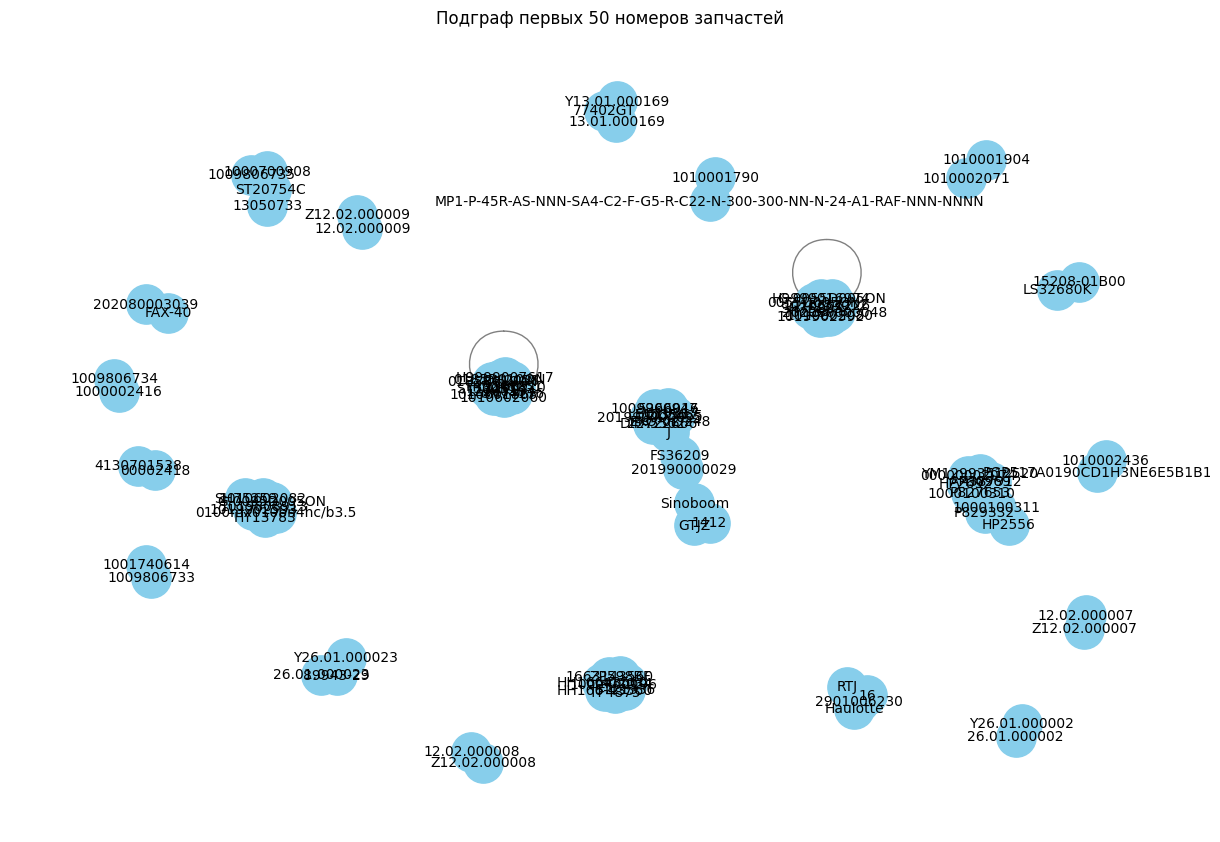

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx


sub_nodes = list(G.nodes)[:100]
H = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H, seed=42) 
nx.draw(H, pos, with_labels=True, node_color='skyblue', node_size=800, font_size=10, edge_color='gray')
plt.title("Подграф первых 50 номеров запчастей")
plt.show()